# Convolutional Neural Nets - CIFAR-10

Έχουμε ήδη δει τις βασικές ιδέες στο [προηγούμενο Notebook με τα δεδομένα του MNIST](https://colab.research.google.com/drive/1SHuJTmahC6w-KoMrcMm4IppIJ3Ycut5H?usp=sharing). Τώρα θα ξανακοιτάξουμε το CIFAR-10. Θυμίζουμε πως τα είδαμε αυτά τα δεδομένα όταν συζητούσαμε δέντρα απόφασης. Καταφέραμε να πετύχουμε ακρίβεια περίπου 25% πάνω στα δεδομένα εκτίμησης (Testing Data).

Θα τα καταφέρουμε πολύ καλύτερα με νευρωνικά δίκτυα. Αλλά θα δούμε επίσης πως δεν είναι εύκολο. Απαιτείται πολύ παραπάνω χρόνος εκπαίδευσης, και επίσης θα χρειαστούμε πιο βαθιά νευρωνικά δίκτυα (πιο πολλά επίπεδα) σε σχέση με αυτά που χρησιμοποιήσαμε επιτυχώς με το MNIST.

Ο σκοπός αυτού του Notebook είναι:
1.   Να συνεχίσουμε να μαθαίνουμε πως να χτίζουμε επίπεδα για να φτιάξουμε βαθιά νευρωνικά δίκτυα.
2. Να μάθουμε πως να χρησιμοποιούμε Convolutional επίπεδα, Maxpool και AveragePool επίπεδα, και τι είναι.
3.   Να μάθουμε τις βασικές ιδέες της εκπαίδευσης για νευρωνικά δίκτυα (συνεχίζοντας αυτά που μάθαμε στο προηγούμενο Notebook).

Και θυμόμαστε τις βασικές ιδέες από το προηγούμενο Notebook: πως κάνουμε το ``model = `` και το ``model.fit(X,y)`` σε νευρωνικά δίκτυα. Είναι μεγαλύτερα τα δίκτυα που θα δούμε εδώ, όπως επίσης και τα δεδομένα.


Επίσης μπορείτε να δείτε:

https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html



```
Κωνσταντίνος Καραμανής: constantine@utexas.edu
http://users.ece.utexas.edu/~cmcaram/
The University of Texas at Austin
Archimedes/Athena RC
```

In [ ]:
import torchvision # provides computer vision functionalities and utilities built on top of PyTorch.
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Set the random seed
torch.manual_seed(42)



## Transforms

Είναι η δεύτερη φορά που αντικρίζουμε τα Transforms. Θα τα ξαναδούμε και στα επόμενα Notebook και θα δούμε πως έχουν και άλλες χρήσεις. Προς το παρόν, είναι ένας τρόπος να κανονικοποιήσουμε τα δεδομένα μας.

Μπορείτε να διαβάσετε παραπάνω εδώ.

https://pytorch.org/vision/stable/transforms.html


In [ ]:
classes = ['αεροπλάνο', 'αυτοκίνητο', 'πτηνό', 'γάτα', 'ελάφι', 'σκύλος', 'βάτραχος', 'άλογο', 'πλοίο', 'φορτηγό']


train_transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])


### Data Loaders

Τα έχουμε ξαναδεί τα Data Loaders στα προηγούμενό μας Notebook.

Μπορείτε να δείτε την συζήτηση εκεί, ή και εδώ:

https://towardsdatascience.com/beginners-guide-to-loading-image-data-with-pytorch-289c60b7afec and then https://stackoverflow.com/questions/51756581/how-do-i-turn-a-pytorch-dataloader-into-a-numpy-array-to-display-image-data-with

https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

## Κατεβάζουμε τα δεδομένα

Στις επόμενες εντολές,

1. Κατεβάζουμε τα δεδομένα, και με την ίδια εντολή εφαρμόζουμε την κανονικοποίηση των transforms.
2. Χωρίζουμε τα δεδομένα σε train/test: αυτά που θα χρησιμοποιήσουμε για εκπαίδευση, και αυτά για εκτίμηση.
3. Δημηιουργούμε τα Data Loaders για τα δεδομένα εκπαίδευσης και εκτίμησης.

In [ ]:
datasets.CIFAR10.url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"


In [ ]:
# download and load training data
train_dataset = datasets.CIFAR10(root='./data', train=True,
                                 download=True, transform=train_transform)

# download and load test data
test_dataset = datasets.CIFAR10(root='./data', train=False,
                                download=True, transform=train_transform)

100%|██████████| 170M/170M [00:12<00:00, 13.4MB/s]


In [ ]:
# data loaders

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Πόσα δεδομένα έχουμε;

50.000 για εκπαίδευση

10.000 για εκτίμηση

In [ ]:
print(len(train_dataset))
print(len(test_dataset))

50000
10000


## Image Visualization

Χρησιμοποιούμε τα Dataloaders για να δούμε τα δεδομένα -- τις εικόνες του CIFAR-10.

πλοίο


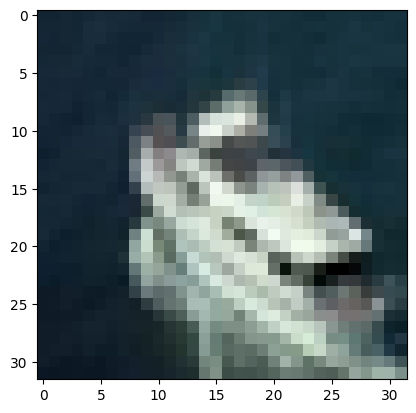

In [ ]:
# Displaying an image from the Dataloader.
# The commands below pick a random element from the data set to display.
# See https://towardsdatascience.com/beginners-guide-to-loading-image-data-with-pytorch-289c60b7afec
# and then https://stackoverflow.com/questions/51756581/how-do-i-turn-a-pytorch-dataloader-into-a-numpy-array-to-display-image-data-with


import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid
%matplotlib inline

dataiter = iter(train_loader)
images, lables = next(dataiter)
images = images / 2 + 0.5     # unnormalize
plt.imshow(np.transpose(images[0].numpy(), (1, 2, 0)))
print(classes[lables[0]])

### Πιο πολλές εικόνες

Χρησιμοποιούμε τις εντολές ``dataiter`` και ``next`` που τις είδαμε και στο προηγούμενο Notebook.

Η εντολή
```
plt.imshow()
```
ζητάει κάθε πίξελ να έχει ένταση που είναι κάποιος πραγματικός αριθμός μεταξύ 0 και 1, ή ακέραιος αριθμός από 0 εώς και 255. Για αυτόν το λόγο χρειαζόμαστε την εντολή
```
img = (img - img.min()) / (img.max() - img.min())
```
Μπορείτε να αφαιρέσετε αυτήν την εντολή να δείτε πως μοιάζουν οι εικόνες.


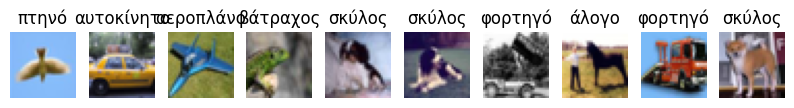

In [ ]:
import matplotlib.pyplot as plt

def show_images(dataloader, classes, k=5):
    """
    Displays k images from the provided DataLoader with their corresponding labels.

    Args:
    dataloader (torch.utils.data.DataLoader): The DataLoader to sample images from.
    classes (list): List of class names corresponding to label indices.
    k (int): Number of images to display.
    """
    # Create an iterator from the dataloader
    dataiter = iter(dataloader)
    images, labels = next(dataiter)  # Use next() to get one batch of images and labels

    plt.figure(figsize=(10, 2 * k))
    for idx in range(min(k, len(images))):  # Ensure we do not go out of bounds
        ax = plt.subplot(1, k, idx + 1)
        img = images[idx].numpy().transpose((1, 2, 0))  # Convert from PyTorch tensor to NumPy array and transpose
        img = (img - img.min()) / (img.max() - img.min())  # Normalize to [0, 1] for visualization

        plt.imshow(img)
        plt.title(classes[labels[idx]])
        plt.axis('off')
    plt.show()

show_images(train_loader, classes, k=10)


## Model Implementation.

Τώρα θα χτίσουμε το CNN. Eδώ θα χρησιμοποιήσουμε

* Convolutional επίπεδα: `nn.Conv2d`
* Max Pooling επίπεδα:`nn.MaxPool2d`
* Average Pooling επίπεδα: `nn.AvgPool2d`
* Fully Connected επίπεδα: `nn.Linear`
* ReLU επίπεδα: `nn.ReLU`


https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html


## Πρώτο CNN

Δίνουμε κάποιες λεπτομέρειες για το κάθε επίπεδο:

```
nn.Conv2d(3,16,7, 2, 3)
```
* Το πρώτο "3" μας λεει πως έχουμε τρία ``channels`` σαν input: αυτό το επίπεδο δέχεται σαν input μία εικόνα με τρία channels, δηλαδή RGB.
* Το "16" μας λέει πως το output του επίπεδου έχει 16 channels.
* Το "7" είναι το ``kernel_size`` και μας λέει πως έχουμε ένα kernel 7 επί 7.
* Το "2" είναι το ``stride`` και το "3" είναι το ``zero-padding.''

Αυτό σημαίνει πως το output μας είναι 16 x 16 x 16.

Η εντολή
```
x = x.mean(dim=(2,3))
```
κοιτάει ξεχωριστά κάθε από τα 16 channels, και αντικαθιστά τις 16 x 16 τιμές με τον μέσο όρο τους, για αυτό λέγεται Average Pooling.

Οπότε το output είναι 16 x 1, δηλαδή έτοιμο να περάσει από το γραμμικό fully-connected επίπεδο
```
self.fc = nn.Linear(16, 10)
```

In [ ]:
class CNNClassifier1(torch.nn.Module):
    def __init__(self):
        """
        Define the layer(s) needed for the model.
        Feel free to define additional input arguments.
        """
        super().__init__()
        self.conv = nn.Conv2d(3, 16, 7, 2, 3)
        self.fc = nn.Linear(16, 10)
        self.relu = nn.ReLU()


    def forward(self, x):
        """
        Define the forward pass of the model.
        """
        # Add convolutional layer
        x = self.conv(x)
        # Add a ReLU
        x = self.relu(x)
        # Add global average pooling
        x = x.mean(dim=(2,3))
        return self.fc(x) # Note: we do not need a softmax if using CrossEntropyLoss (see optimization function)

    def predict(self, image):
        return self(image).argmax(1)


In [ ]:
# Πόσες παραμέτρους έχει το μοντέλο μας
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Model Training and Validation


In [ ]:
# εάν είναι διαθέσιμο το GPU, το χρησιμοποιούμε
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

### Optimization

Δηλαδή: ``model.fit(X,y)``

Ο κώδικας είναι πιο περίπλοκος. Η ιδέα είναι ίδια. Και αυτό το έχουμε ξαναδεί στο [προηγούμενο Notebook](https://colab.research.google.com/drive/1SHuJTmahC6w-KoMrcMm4IppIJ3Ycut5H?usp=sharing). Δείτε εκεί για πιο εκτενή συζήτηση των εντολών.

In [ ]:
from torch import optim

import torch
import copy
import torch.nn.functional as F
import matplotlib.pyplot as plt

def train(model, train_loader, test_loader, optimizer, epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # criterion
    criterion = torch.nn.CrossEntropyLoss()

    # scheduler
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)


    train_losses = []
    test_losses = []
    test_accuracies = []  # List to store accuracy for each epoch
    best_accuracy = 0  # Best accuracy found
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()  # Update the learning rate

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        total_test_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_test_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_loss = total_test_loss / len(test_loader)
        epoch_accuracy = correct / total
        test_losses.append(epoch_loss)
        test_accuracies.append(epoch_accuracy)

        if epoch_accuracy > best_accuracy:
            best_accuracy = epoch_accuracy
            best_model_wts = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {train_losses[-1]}, Testing Loss: {test_losses[-1]}, Testing Accuracy: {epoch_accuracy:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)
    print(f"Loaded the best model from epoch {best_epoch} with Testing Accuracy: {best_accuracy:.4f}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs+1), train_losses, label='Training Loss')
    plt.plot(range(1, epochs+1), test_losses, label='Testing Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs+1), test_accuracies, label='Testing Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

    return # train_losses, test_losses, test_accuracies, best_accuracy

In [ ]:
def evaluate(model, data_loader, device):
    model.eval()  # Set model to evaluate mode
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

## Δίνουμε την εντολή για την εκπαίδευση

In [ ]:
# Εκπαιδεύουμε το πρώτο μοντέλο
#

torch.manual_seed(42)

model = CNNClassifier1()

# optimization
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

# epochs
epochs = 5
train(model, train_loader, test_loader, optimizer, epochs)



### Αυξάνεται η Ακρίβεια του Μοντέλου

Βλέπουμε πρόοδο στα πρώτα 5 epochs της εκπαίδευσης, και πέφτουν μαζί το Training Loss και Testing Loss.

Οπότε δεν έχουμε δεί ακόμα τα όρια αυτού του δικτύου. Αξίζει να συνεχίσουμε να το εκπαιδεύουμε.

Μπορούμε να συνεχίσουμε την εκπαίδευση.

**Προσοχή**: εάν ξαναδώσουμε την εντολή ``model = CNNClassifier1()`` τότε οι παράμετροι του μοντέλου αρχικοποιούνται, δηλαδή, χάνουμε οποιαδήποτε εκπαίδευση έχει γίνει, και η διαδικασία αρχίζει από την αρχή.

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
epochs = 5
train(model, train_loader, test_loader, optimizer, epochs)

## Συνεχίζουμε!

Ακόμα φαίνεται πως υπάρχει βελτίωση. Οπότε συνεχίζουμε την εκπαίδευση.

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
epochs = 5
train(model, train_loader, test_loader, optimizer, epochs)

## Σταθεροποίηση

Βλέπουμε πως η άνωδος της ακρίβειας έχει σταματήσει. Μάλλον έχουμε φτάσει στα όρια αυτού του απλού δικτύου.

Για να είμαστε σίγουροι, συνεχίζουμε λίγο ακόμα την εκπαίδευση.

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
epochs = 5
train(model, train_loader, test_loader, optimizer, epochs)

In [ ]:
# Εκτιμούμε την ακρίβεια
# Φαίνεται πως κάτι έχουμε μάθει
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        # calculate outputs by running images through the network
        outputs = model(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

## Φτάσαμε το 34% Ακρίβεια

Αυτό το νευρωνικό δίκτυο έχει βελτιώσει την απόδοση μας σε σχέση με τα δέντρα απόφασης.

Το νευρωνικό μας έχει πάνω από 2.500 παραμέτρους.

In [ ]:
count_trainable_parameters(model)

# Πιο Βαθύ Μοντέλο

Αφήνουμε το απλό νευρωνικό, και περνάμε σε ένα πιο βαθύ δίκτυο, με παραπάνω νευρώνες.

### **Άσκηση**

Μπορείτε να αναλύσετε κάθε επίπεδο όπως κάναμε παραπάνω;
Κάνουμε εμείς την αρχή:

* ``self.conv1 = nn.Conv2d(3, 6, 5)``
Το input είναι 3 x 32 x 32. Αυτό το επίπεδο δέχεται input με τρία channels (οπότε ταιριάζει με τα δεδομένα μας), και σαν output βγάζει 6 channels. Το "5" μας λέει πως το kernel είναι 5 επί 5. Δέν δίνουμε οδηγίες για stride ή zero-padding που σημαίνει πως έχουμε ``stride=1`` και ``zero-padding = 0``. Οπότε το output μας είναι 6 x 28 x 28 -- έξι channels, το καθένα 28 x 28.
* ``self.pool = nn.MaxPool2d(2, 2)``
To πρώτο "2" μας λέει πως το kernel είναι 2 επί 2. Το δεύτερο "2" είναι το stride, οπότε έχουμε ``stride = 2``. Αυτό σημαίνει πως κοιτάμε κάμε 2 x 2 κουτάκι (ξεχωριστά σε κάθε channel) και αντικαθιστούμε αυτούς τους 4 αριθμούς που περιέχει το κουτάκι, με τον μέγιστο αριθμό. Οπότε το output μας είνανι 6 x 14 x 14 -- έξι channels, το κάθένα 14 x 14.
* **Συνεχίστε εσείς**

In [ ]:
# CNNClassifier2: από το pytorch tutorial
class CNNClassifier2(nn.Module):
    def __init__(self):
        super().__init__()
        self.relu = nn.ReLU()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x # Note: we do not need a softmax is using CrossEntropyLoss (see optimization function)

In [ ]:
# Εκπαιδεύουμε το δεύτερο μοντέλο. Θα δούμε πως πετυχαίνει πολύ καλύτερη
# ακρίβεια, σε σχέση με το πρώτο.
#
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Choose a model to train
model2 = CNNClassifier2()
model2.to(device)
model2.train()



## Πολύ Μεγαλύτερο Δίκτυο

Βλέπουμε πως έχουμε ένα πολύ πιο πλούσιο μοντέλο. Ενώ το προηγούμενο είχε 2.538 παραμέτρους, αυτό έχει περίπου 25 φορές παραπάνω: 62.006 παραμέτρους.

In [ ]:
count_trainable_parameters(model2)

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(model2.parameters(), lr=0.001, weight_decay=1e-4)
epochs = 5
train(model2, train_loader, test_loader, optimizer, epochs)

## Συνεχίζουμε!

Το σφάλμα πέφτει, και η ακρίβεια ανεβαίνει. Οπότε συνεχίζουμε την εκπαίδευση.

Θυμίζουμε πως δεν πρέπει να ξαναδώσουμε την εντολή
```
model2 = CNNClassifier2()
```
όταν συνεχίζουμε την εκπαίδευση, αλλιώς αρχίζουμε από την αρχή.

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(model2.parameters(), lr=0.0001, weight_decay=1e-4)
epochs = 5
train(model2, train_loader, test_loader, optimizer, epochs)

## Φτάσαμε στα όρια του δικτύου

Φαίνεται πως η βελτίωση ακρίβειας έχει επιβραδύνει. Γιά να είμαστε σίγουροι εκπαιδεύουμε για ακόμα 5 epochs.

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(model2.parameters(), lr=0.0001, weight_decay=1e-4)
epochs = 5
train(model2, train_loader, test_loader, optimizer, epochs)

## Πως τα πήγαμε

Βλέπουμε πως πετύχαμε πολύ μεγάλη βελτίωση σε σχέση με το προηγούμενό μας δίκτυο.


In [ ]:
# Assessing accuracy on the entire data set
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        # calculate outputs by running images through the network
        outputs = model2(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

# Ακόμα Πιο Βαθύ Δίκτυο

Θα προσπαθήσουμε άλλη μιά φορά, τώρα με ακόμα πιο βαθύ δίκτυο με πολλές παραπάνω παραμέτρους.

Πολλά στοιχία είναι πιά γνώριμα. Βλέπουμε πως έχουμε
* ``nn.Conv2d``
* ``nn.ReLU``
* ``nn.MaxPool2d``
* ``nn.Linear``

αλλά έχουμε και δύο καινούργια επίπεδα:
* ``nn.BatchNorm2d`` εφαρμόζει μία κανονικοποίηση στις τιμές που παίρνουν οι νευρώνες σε κάθε channel στο επίπεδο όπου εφαρμόζεται το BatchNorm.
* ``nn.Dropout`` Το Dropout είναι ένα επίπεδο που χρησιμοποιείται σε πιο βαθιά δίκτυα, σαν τεχνική για να αποφύγουμε την υπερμοντελοποίηση. Δέν μπαίνουμε σε παραπάνω λεπτομέρειες εδώ. Μπορείτε να διαβάσετε παραπάνω [εδώ](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html).

In [ ]:
# Define the CNN architecture
class CNNClassifierDeep(nn.Module):
    def __init__(self):
        super(CNNClassifierDeep, self).__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.05),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.fc_layer = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = x.view(x.size(0), -1)  # Flatten the layer
        x = self.fc_layer(x)
        return x # Note: we do not need a softmax is using CrossEntropyLoss (see optimization function)

In [ ]:
model3 = CNNClassifierDeep()


## Πόσες Παραμέτρους Έχει;

Το τελευταίο μας δίκτυο έχει σχεδόν 6.000.000 παραμέτρους!

In [ ]:
count_trainable_parameters(model3)

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(model3.parameters(), lr=0.001, weight_decay=1e-4)
epochs = 5
train(model3, train_loader, test_loader, optimizer, epochs)

## Συνεχίζουμε

Όσο βλέπουμε βελτίωση, συνεχίζουμε την εκπαίδευση.

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(model3.parameters(), lr=0.0001, weight_decay=1e-4)
epochs = 5
train(model3, train_loader, test_loader, optimizer, epochs)

In [ ]:
optimizer = optim.Adam(model3.parameters(), lr=0.0001, weight_decay=1e-4)
epochs = 5
train(model3, train_loader, test_loader, optimizer, epochs)

### Πώς τα πήγαμε

In [ ]:
evaluate(model3, test_loader, device)

## **Άσκηση**: Πού Δεν Τα Πήγαμε Καλά;

Εάν θέλαμε σοβαρά να κοιτάξουμε αυτά τα δεδομένα και να φτιάξουμε αλγόριθμο ταξινόμησης (είτε νευρωνικό δίκτυο, είτα κάτι άλλο) πρέπει να καταλάβουμε **που** κάνουμε λάθη.

Σας το αφήνουμε για άσκηση. (Κάναμε κάτι παρόμοιο στο προηγούμενο Notebook).

## Μοντέλα, Επίπεδα και Παράμετροι

Ας συγκρίνουμε τώρα τα μοντέλα μας. Εώς τώρα έχουμε δεί πως η αποτελεσματικότητα διαφέρει πολύ. Αλλά και το μέγεθος επίσης διαφέρει.

Θα χρησιμοποιήσουμε τις εντολές

```
from torchsummary import summary
```
και
```
for name, layer in model2.named_modules():
    print(name,layer)
```
Η δεύτερη είναι πολύ χρήσιμη όταν κατεβάζουμε δίκτυο που έχει χτίσει/εκπαιδεύσει άλλος.

In [ ]:
# Βλέπουμε αναλυτικά το δίκτυο που δημιουργήσαμε
from torchsummary import summary

summary(model,(3,32,32))


In [ ]:
summary(model2,(3,32,32))


In [ ]:
summary(model3,(3,32,32))

## Summary

* Εκπαιδεύσαμε 3 Convolutional νευρωνικά δίκτυα. Το πρώτο με περίπου 2.500 παραμέτρους, το δεύτερο με περίπου 65.000, και το τελευταίο με σχεδόν 6.000.000 παραμέτρους.

* Η ακρίβεια στα δεδομένα ανέβηκε σημαντικά. Αλλά είδαμε πως δεν ήταν εύκολο. Χρειάστηκε πολύ μεγαλύτερο δίκτυο, και ο χρόνος εκπαίδευσης ήταν πολύ μεγαλύτερος.

* Επίσης, μάθαμε και κάποιες καινούργιες χρήσιμες εντολές:
  * Χρησιμοποιήσαμε κάποια καινούργια επίπεδα
  * Μάθαμε την εντολή για επισκόπηση νευρωνικών δικτύων. Αυτή η εντολή θα φανεί πολύ χρήσιμη όταν αρχίσουμε το Transfer Learning. Εκεί, θα χρησιμοποιούμε δίκτυα που έχουν χτίσει και εκπαιδεύσει άλλοι, και θα πρέπει να μπορούμε να δούμε τα μεγέθη των επιπέδων, και πως έχουνε ονομαστεί στο μοντέλο.